In [44]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, TimeDistributed, Dropout
from tensorflow.keras.callbacks import EarlyStopping



print(f'TensorFlow  : {tf.__version__}')
print(f'NumPy       : {np.__version__}')
print(f'Pandas      : {pd.__version__}')
print('Environment ready.')

TensorFlow  : 2.21.0
NumPy       : 2.3.5
Pandas      : 2.3.3
Environment ready.


In [45]:
df_full = pd.read_csv('C:/Users/Admin/Desktop/Melanija needs/DIPLOMNA/monthly_full_release_long_format.csv', low_memory=False)


In [46]:
print("=" * 60)
print("ОБЩА ИНФОРМАЦИЯ")
print("=" * 60)
print(f"Общо редове    : {len(df_full):,}")
print(f"Общо колони    : {df_full.shape[1]}")
print(f"Колони         : {df_full.columns.tolist()}")
print(f"Период         : {df_full['Date'].min()} → {df_full['Date'].max()}")

ОБЩА ИНФОРМАЦИЯ
Общо редове    : 498,742
Общо колони    : 18
Колони         : ['Area', 'ISO 3 code', 'Date', 'Area type', 'Continent', 'Ember region', 'EU', 'OECD', 'G20', 'G7', 'ASEAN', 'Category', 'Subcategory', 'Variable', 'Unit', 'Value', 'YoY absolute change', 'YoY % change']
Период         : 1998-12-01 → 2026-02-01


In [47]:
print("\n" + "=" * 60)
print("СТРАНИ")
print("=" * 60)
print(f"Общо страни    : {df_full['Area'].nunique()}")
print(f"\nEU страни:")
print(sorted(df_full[df_full['EU']==1.0]['Area'].unique()))
print(f"\nИма ли България: {'Bulgaria' in df_full['Area'].values}")


СТРАНИ
Общо страни    : 98

EU страни:
['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']

Има ли България: True


In [48]:
print("\n" + "=" * 60)
print("VARIABLES (какво се мери)")
print("=" * 60)
print(df_full['Variable'].unique())



VARIABLES (какво се мери)
['Demand' 'Clean' 'Fossil' 'Gas and Other Fossil'
 'Hydro, Bioenergy and Other Renewables' 'Renewables' 'Wind and Solar'
 'Bioenergy' 'Coal' 'Gas' 'Hydro' 'Nuclear' 'Other Fossil' 'Solar' 'Wind'
 'Total Generation' 'Net Imports' 'CO2 intensity' 'Total emissions'
 'Other Renewables' 'Day-ahead electricity price']


In [49]:
print("\n" + "=" * 60)
print("МЕРНИ ЕДИНИЦИ")
print("=" * 60)
print(df_full['Unit'].unique())


МЕРНИ ЕДИНИЦИ
['TWh' '%' 'mtCO2' 'gCO2/kWh' 'EUR/MWh']


In [50]:
print("\n" + "=" * 60)
print("NULL СТОЙНОСТИ")
print("=" * 60)
print(df_full.isnull().sum())


NULL СТОЙНОСТИ
Area                        0
ISO 3 code              55298
Date                        0
Area type                   0
Continent               55298
Ember region            55298
EU                      55298
OECD                    55298
G20                     55298
G7                      55298
ASEAN                   55298
Category                    0
Subcategory                 0
Variable                    0
Unit                        0
Value                    2518
YoY absolute change    185123
YoY % change           232335
dtype: int64


In [51]:
print("\n" + "=" * 60)
print("ПРИМЕРНИ ДАННИ ЗА DEMAND (първите 10 страни)")
print("=" * 60)
demand = df_full[
    (df_full['Variable'] == 'Demand') &
    (df_full['Unit'] == 'TWh')
][['Area','Date','Value']].dropna()
print(f"Записи за Demand: {len(demand):,}")
print(f"Страни с Demand : {demand['Area'].nunique()}")
print(demand['Area'].unique()[:20])


ПРИМЕРНИ ДАННИ ЗА DEMAND (първите 10 страни)
Записи за Demand: 11,479
Страни с Demand : 98
['Argentina' 'Armenia' 'ASEAN' 'Asia' 'Australia' 'Austria' 'Azerbaijan'
 'Bangladesh' 'Belarus' 'Belgium' 'Bolivia' 'Bosnia Herzegovina' 'Brazil'
 'Bulgaria' 'Canada' 'Chile' 'China' 'Colombia' 'Costa Rica' 'Croatia']


In [52]:
bg = df_full[
    (df_full['Area'] == 'Bulgaria') &
    (df_full['Variable'] == 'Demand') &
    (df_full['Unit'] == 'TWh')
][['Date', 'Value']].copy()

In [53]:
bg.columns = ['date', 'consumption_MWh']
bg['date'] = pd.to_datetime(bg['date'])
bg = bg.sort_values('date').reset_index(drop=True)
bg = bg.dropna(subset=['consumption_MWh'])

In [54]:
bg['consumption_MWh'] = (bg['consumption_MWh'] * 1_000_000).round(1)


In [55]:
bg['target'] = bg['consumption_MWh']
df = bg.copy()

In [56]:
print(f'Shape   : {df.shape}')
print(f'Period  : {df.date.iloc[0].date()} → {df.date.iloc[-1].date()}')
print(f'Records : {len(df)}')
print(f'Range   : {df.consumption_MWh.min():,.0f} – {df.consumption_MWh.max():,.0f} MWh')
print(f'Nulls   : {df.isnull().sum().sum()}')


Shape   : (134, 3)
Period  : 2015-01-01 → 2026-02-01
Records : 134
Range   : 2,330,000 – 4,540,000 MWh
Nulls   : 0


In [57]:
df[['date','consumption_MWh']].head(6)

,date,consumption_MWh
0,2015-01-01,4360000.0
1,2015-02-01,4110000.0
2,2015-03-01,4200000.0
3,2015-04-01,2900000.0
4,2015-05-01,2670000.0
5,2015-06-01,2620000.0


In [58]:
df[['date','consumption_MWh']].tail(6)

,date,consumption_MWh
128,2025-09-01,2440000.0
129,2025-10-01,2830000.0
130,2025-11-01,3010000.0
131,2025-12-01,3560000.0
132,2026-01-01,4030000.0
133,2026-02-01,3520000.0


In [59]:
print(bg.columns)

Index(['date', 'consumption_MWh', 'target'], dtype='object')


In [60]:
print("=" * 60)
print('Bulgaria monthly electricity demand — dataset info:')

print("EDA — STATISTICAL ANALYSIS")
print("=" * 60)
display(df[['consumption_MWh']].describe().round(0))

print(f"\nTotal null values: {df.isnull().sum().sum()}")

Bulgaria monthly electricity demand — dataset info:
EDA — STATISTICAL ANALYSIS


,consumption_MWh
count,134.0
mean,3129478.0
std,484382.0
min,2330000.0
25%,2770000.0
50%,2970000.0
75%,3467500.0
max,4540000.0



Total null values: 0


In [61]:
print("Oбобщена информация за българската месечна консумация:")
print(f"Null values: {df.isnull().sum().sum()}")

df[['date','consumption_MWh']].describe().round(0)

Oбобщена информация за българската месечна консумация:
Null values: 0


,date,consumption_MWh
count,134,134.0
mean,2020-07-16 13:04:28.656716544,3129478.0
min,2015-01-01 00:00:00,2330000.0
25%,2017-10-08 18:00:00,2770000.0
50%,2020-07-16 12:00:00,2970000.0
75%,2023-04-23 12:00:00,3467500.0
max,2026-02-01 00:00:00,4540000.0
std,NaN,484382.0


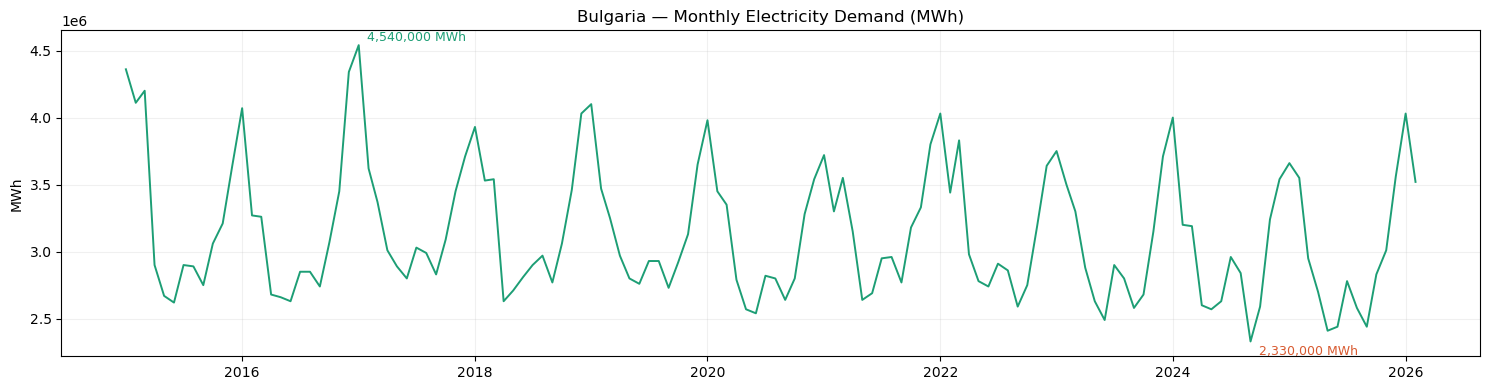

In [62]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df['date'], df['consumption_MWh'], color='#1D9E75', lw=1.4)
ax.set_title('Bulgaria — Monthly Electricity Demand (MWh)', fontsize=12)
ax.set_ylabel('MWh')
ax.grid(True, alpha=0.18)


peak_idx  = df['consumption_MWh'].idxmax()
trough_idx = df['consumption_MWh'].idxmin()
ax.annotate(f'{df.consumption_MWh.max():,.0f} MWh',
            xy=(df.date.iloc[peak_idx], df.consumption_MWh.max()),
            xytext=(6, 3), textcoords='offset points', fontsize=9, color='#1D9E75')
ax.annotate(f'{df.consumption_MWh.min():,.0f} MWh',
            xy=(df.date.iloc[trough_idx], df.consumption_MWh.min()),
            xytext=(6, -10), textcoords='offset points', fontsize=9, color='#D85A30')

plt.tight_layout()
plt.show()

In [63]:
df.loc[df['consumption_MWh'].idxmax()]

date               2017-01-01 00:00:00
consumption_MWh              4540000.0
target                       4540000.0
Name: 24, dtype: object

In [64]:
df.loc[df['consumption_MWh'].idxmin()]

date               2024-09-01 00:00:00
consumption_MWh              2330000.0
target                       2330000.0
Name: 116, dtype: object

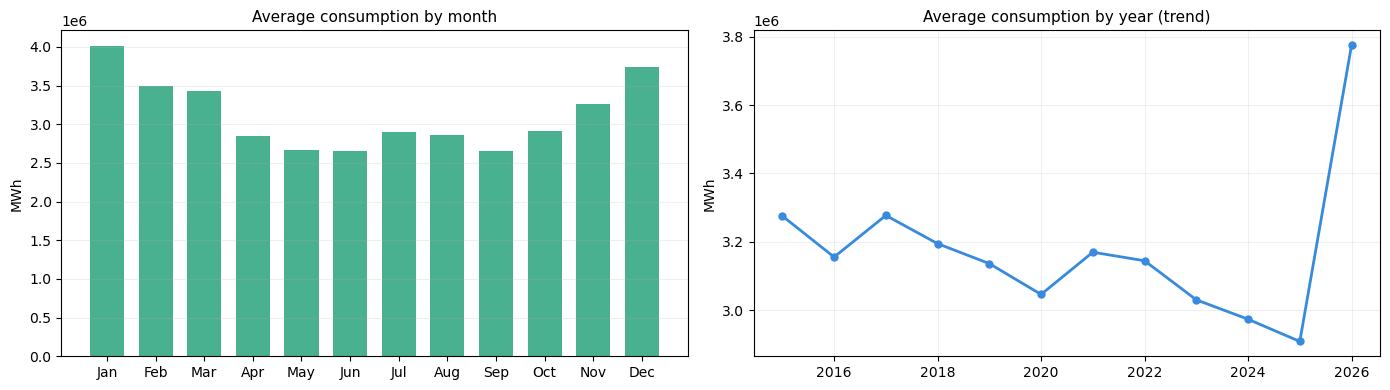

Peak month   : 1 (Jan=1)
Trough month : 6 (Jun=6)
Seasonal amplitude: 1,364,167 MWh

Peak year    : 2026
Trough year  : 2025
Trend range  : 865,833 MWh


In [65]:

monthly_avg = df.groupby(df.date.dt.month)['consumption_MWh'].mean()
yearly_avg  = df.groupby(df.date.dt.year)['consumption_MWh'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly pattern
axes[0].bar(monthly_avg.index, monthly_avg.values,
            color='#1D9E75', alpha=0.8, width=0.7, edgecolor='none')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].set_title('Average consumption by month', fontsize=11)
axes[0].set_ylabel('MWh')
axes[0].grid(axis='y', alpha=0.2)

# Yearly trend
axes[1].plot(yearly_avg.index, yearly_avg.values,
             color='#378ADD', lw=2, marker='o', markersize=5)
axes[1].set_title('Average consumption by year (trend)', fontsize=11)
axes[1].set_ylabel('MWh')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'Peak month   : {monthly_avg.idxmax()} (Jan=1)')
print(f'Trough month : {monthly_avg.idxmin()} (Jun=6)')
print(f'Seasonal amplitude: {monthly_avg.max() - monthly_avg.min():,.0f} MWh')

print()

print(f'Peak year    : {yearly_avg.idxmax()}')
print(f'Trough year  : {yearly_avg.idxmin()}')
print(f'Trend range  : {yearly_avg.max() - yearly_avg.min():,.0f} MWh')

In [66]:

WINDOW = 12    
LAG    = 12   
TEST_N = 12    

# ── Train / Test split 
split_idx = len(df) - TEST_N
train = df.iloc[:split_idx].copy().reset_index(drop=True)
test  = df.iloc[split_idx:].copy().reset_index(drop=True)

print()
print(f'Train  : {len(train)} records  {train.date.iloc[0].date()} → {train.date.iloc[-1].date()}')
print(f'Test   : {len(test)} records  {test.date.iloc[0].date()}  → {test.date.iloc[-1].date()}')
print()


Train  : 122 records  2015-01-01 → 2025-02-01
Test   : 12 records  2025-03-01  → 2026-02-01



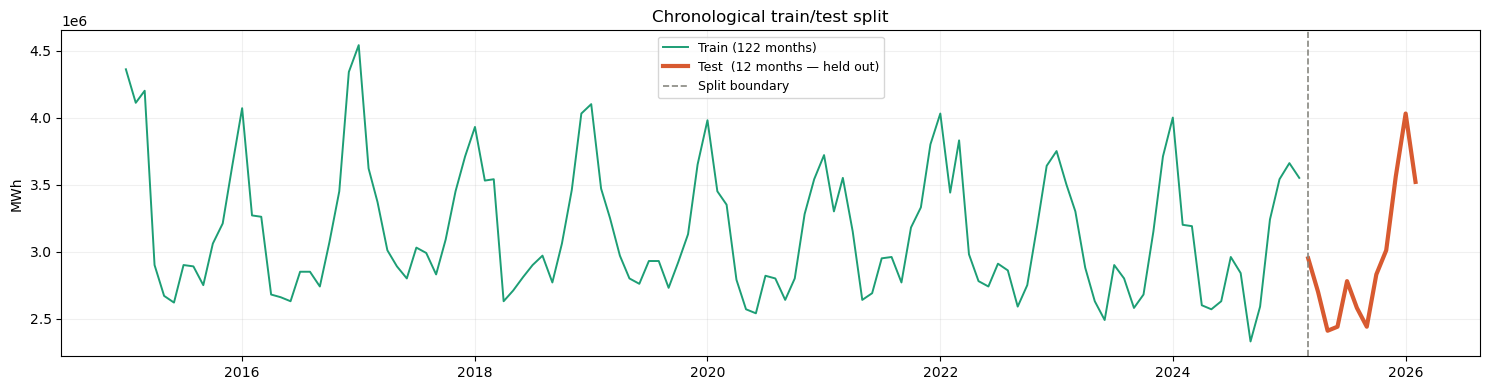

In [67]:
# ── Visual confirmation ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train.date, train.target, color='#1D9E75', lw=1.4, label=f'Train ({len(train)} months)')
ax.plot(test.date,  test.target,  color='#D85A30', lw=3.0, label=f'Test  ({len(test)} months — held out)')
ax.axvline(test.date.iloc[0], color='#888780', ls='--', lw=1.2, label='Split boundary')
ax.set_title('Chronological train/test split')
ax.set_ylabel('MWh')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.18)
plt.tight_layout()
plt.show()

In [68]:
# ── Normalization: fit on TRAIN ONLY ───────────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[['target']]).flatten()

print(f'Original range : {train.target.min():,.1f} – {train.target.max():,.1f} MWh')
print(f'Scaled range   : {train_scaled.min():.4f} – {train_scaled.max():.4f}')
print()


Original range : 2,330,000.0 – 4,540,000.0 MWh
Scaled range   : 0.0000 – 1.0000



In [69]:
# ── Sliding window function ────────────────────────────────────────────────
def create_sequences(series: np.ndarray, window: int, lag: int):
   
    X, y = [], []
    for i in range(len(series) - window - lag + 1):
        X.append(series[i : i + window])
        y.append(series[i + window + lag - 1])
    return np.array(X), np.array(y)


X, y = create_sequences(train_scaled, WINDOW, LAG)

# 80/20 split within training data for validation during training
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1, shuffle=False
)

# Reshape: 2D → 3D for CNN/LSTM  [samples, timesteps, features]
X_tr_3d  = X_tr.reshape(*X_tr.shape,   1)
X_val_3d = X_val.reshape(*X_val.shape, 1)

print(f'Total sequences   : {len(X)}')
print(f'Train sequences   : {X_tr.shape}   (MLP input)')
print(f'Val   sequences   : {X_val.shape}')
print(f'Train 3D          : {X_tr_3d.shape}  (CNN/LSTM input)')

Total sequences   : 99
Train sequences   : (79, 12)   (MLP input)
Val   sequences   : (20, 12)
Train 3D          : (79, 12, 1)  (CNN/LSTM input)


In [70]:
# ── Shared training config ─────────────────────────────────────────────────
EPOCHS     = 60
BATCH_SIZE = 16
# EarlyStopping: stop if val_loss doesn't improve for 10 consecutive epochs
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=0)

histories = {}
models    = {}
palette   = {'MLP':'#378ADD', 'CNN':'#BA7517', 'LSTM':'#1D9E75'}


print("Training configuration ready.")

Training configuration ready.


In [71]:
model_mlp = Sequential([
    Dense(100, activation='relu', input_shape=(WINDOW,)),
    Dropout(0.1),
    Dense(50,  activation='relu'),
    Dense(1)
], name='MLP')

model_mlp.compile(loss='mse', optimizer='adam')
model_mlp.summary()

histories['MLP'] = model_mlp.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=0
)
models['MLP'] = model_mlp
stopped = len(histories['MLP'].history['loss'])
print(f'MLP: stopped at epoch {stopped}. val_loss = {histories["MLP"].history["val_loss"][-1]:.5f}')

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 100)            │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

MLP: stopped at epoch 31. val_loss = 0.00666


In [72]:
model_cnn = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu',
           input_shape=(WINDOW, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.1),
    Dense(1)
], name='CNN')

model_cnn.compile(loss='mse', optimizer='adam')
model_cnn.summary()

histories['CNN'] = model_cnn.fit(
    X_tr_3d, y_tr,
    validation_data=(X_val_3d, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=0
)
models['CNN'] = model_cnn
stopped = len(histories['CNN'].history['loss'])
print(f'CNN: stopped at epoch {stopped}. val_loss = {histories["CNN"].history["val_loss"][-1]:.5f}')

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 11, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50)             │        16,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,293 (63.64 KB)

 Trainable params: 16,293 (63.64 KB)

 Non-trainable params: 0 (0.00 B)

CNN: stopped at epoch 10. val_loss = 0.03309


In [73]:
model_lstm = Sequential([
    LSTM(units=50, activation='relu', input_shape=(WINDOW, 1)),
    Dropout(0.2),
    Dense(1)
], name='LSTM')

model_lstm.compile(loss='mse', optimizer='adam')
model_lstm.summary()

histories['LSTM'] = model_lstm.fit(
    X_tr_3d, y_tr,
    validation_data=(X_val_3d, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=0
)
models['LSTM'] = model_lstm
stopped = len(histories['LSTM'].history['loss'])
print(f'LSTM: stopped at epoch {stopped}. val_loss = {histories["LSTM"].history["val_loss"][-1]:.5f}')

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

LSTM: stopped at epoch 10. val_loss = 0.03923


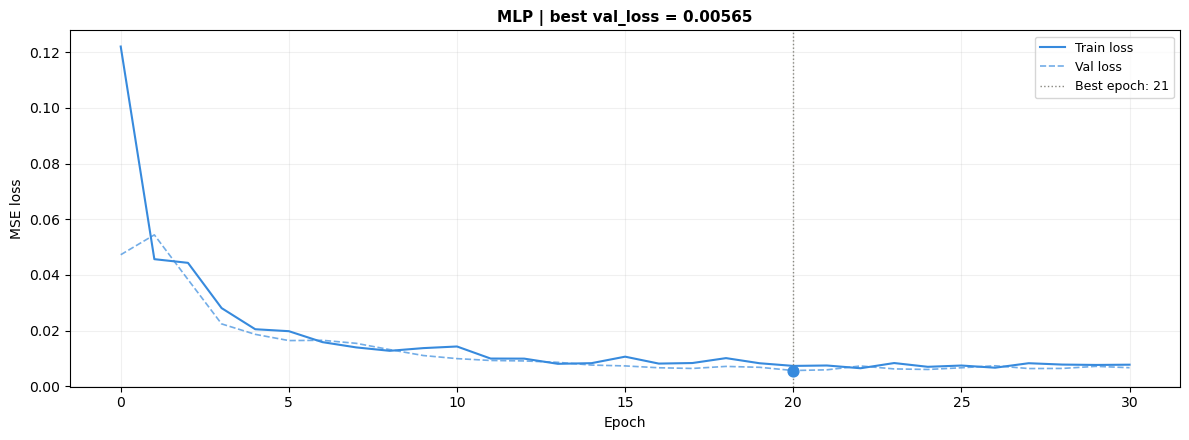

In [74]:
hist = histories['MLP']

train_loss = hist.history['loss']
val_loss   = hist.history['val_loss']

best_epoch = np.argmin(val_loss)

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(
    train_loss,
    color=palette['MLP'],
    lw=1.5,
    label='Train loss'
)

ax.plot(
    val_loss,
    color=palette['MLP'],
    lw=1.2,
    ls='--',
    alpha=0.7,
    label='Val loss'
)

ax.axvline(
    best_epoch,
    color='#888780',
    ls=':',
    lw=1,
    label=f'Best epoch: {best_epoch+1}'
)
ax.scatter(
    [best_epoch],
    [val_loss[best_epoch]],
    color=palette['MLP'],
    s=60,
    zorder=5
)

ax.set_title(
    f'MLP | best val_loss = {val_loss[best_epoch]:.5f}',
    fontsize=11,
    fontweight='bold'
)

ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.18)

plt.tight_layout()
plt.show()


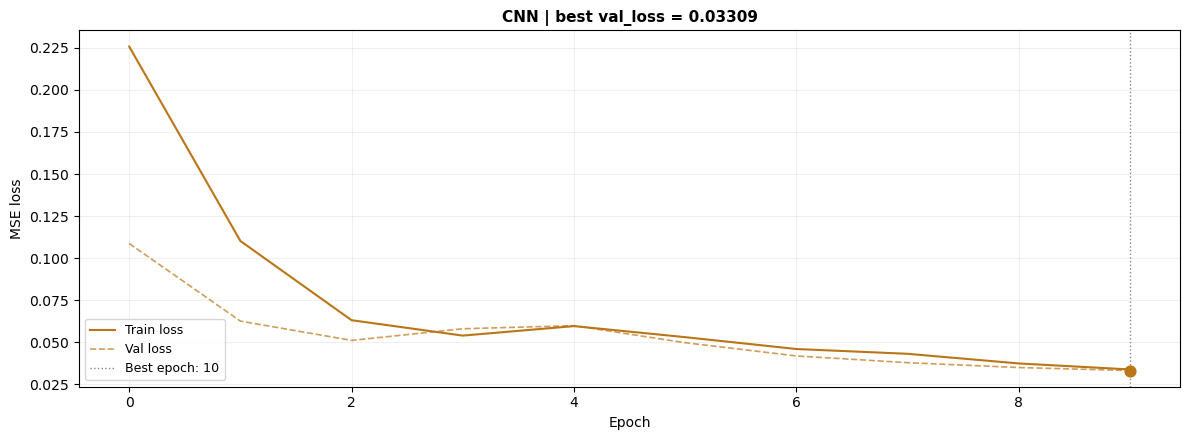

In [75]:
hist = histories['CNN']

train_loss = hist.history['loss']
val_loss   = hist.history['val_loss']

best_epoch = np.argmin(val_loss)

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(
    train_loss,
    color=palette['CNN'],
    lw=1.5,
    label='Train loss'
)

ax.plot(
    val_loss,
    color=palette['CNN'],
    lw=1.2,
    ls='--',
    alpha=0.7,
    label='Val loss'
)

ax.axvline(
    best_epoch,
    color='#888780',
    ls=':',
    lw=1,
    label=f'Best epoch: {best_epoch+1}'
)
ax.scatter(
    [best_epoch],
    [val_loss[best_epoch]],
    color=palette['CNN'],
    s=60,
    zorder=5
)

ax.set_title(
    f'CNN | best val_loss = {val_loss[best_epoch]:.5f}',
    fontsize=11,
    fontweight='bold'
)

ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.18)

plt.tight_layout()
plt.show()



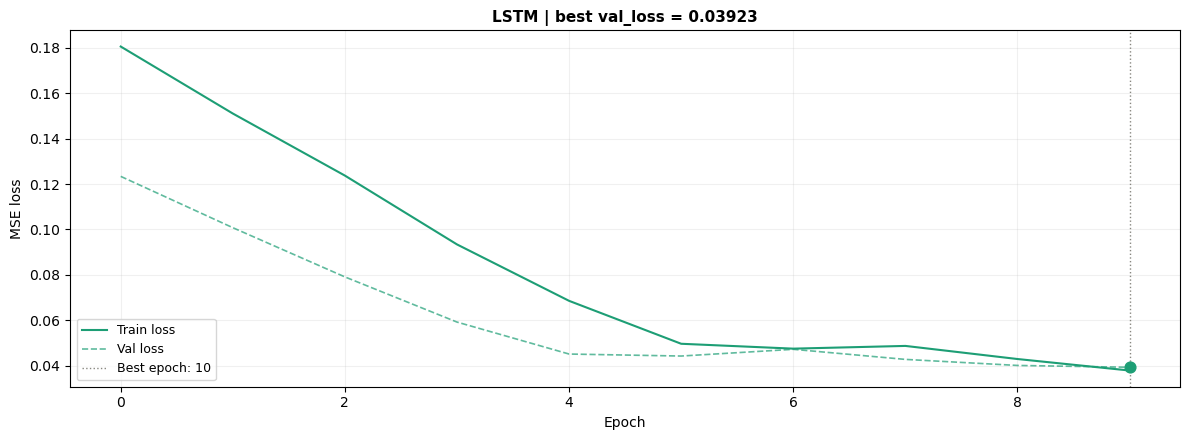

In [76]:
hist = histories['LSTM']

train_loss = hist.history['loss']
val_loss   = hist.history['val_loss']

best_epoch = np.argmin(val_loss)

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(
    train_loss,
    color=palette['LSTM'],
    lw=1.5,
    label='Train loss'
)

ax.plot(
    val_loss,
    color=palette['LSTM'],
    lw=1.2,
    ls='--',
    alpha=0.7,
    label='Val loss'
)

ax.axvline(
    best_epoch,
    color='#888780',
    ls=':',
    lw=1,
    label=f'Best epoch: {best_epoch+1}'
)
ax.scatter(
    [best_epoch],
    [val_loss[best_epoch]],
    color=palette['LSTM'],
    s=60,
    zorder=5
)

ax.set_title(
    f'LSTM | best val_loss = {val_loss[best_epoch]:.5f}',
    fontsize=11,
    fontweight='bold'
)

ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.18)

plt.tight_layout()
plt.show()

In [77]:
# ── RMSE and MAPE on validation set ────────────────────────────────────────

def get_X(name):
    return X_val if name == 'MLP' else X_val_3d


def evaluate(name, model, X_in, y_true):

    y_pred_s = model.predict(X_in, verbose=0).flatten()

    y_pred = scaler.inverse_transform(
        y_pred_s.reshape(-1,1)
    ).flatten()

    y_real = scaler.inverse_transform(
        y_true.reshape(-1,1)
    ).flatten()

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    mape = np.mean(
        np.abs((y_real - y_pred) / y_real)
    ) * 100

    return rmse, mape, y_pred, y_real


results = {
    name: evaluate(name, model, get_X(name), y_val)
    for name, model in models.items()
}



print(f'{"Model":<12}  {"RMSE (MWh)":>12}  {"MAPE (%)":>10}  {"Params":>10}')
print('─' * 52)

for name, (rmse, mape, _, _) in results.items():

    n_params = models[name].count_params()



    print(
        f'{name:<12}  '
        f'{rmse:>12,.1f}  '
        f'{mape:>9.2f}%  '
        f'{n_params:>10,}'
    )

Model           RMSE (MWh)    MAPE (%)      Params
────────────────────────────────────────────────────
MLP              166,161.1       4.54%       6,401
CNN              728,475.7      17.44%      16,293
LSTM             776,217.3      19.30%      10,451


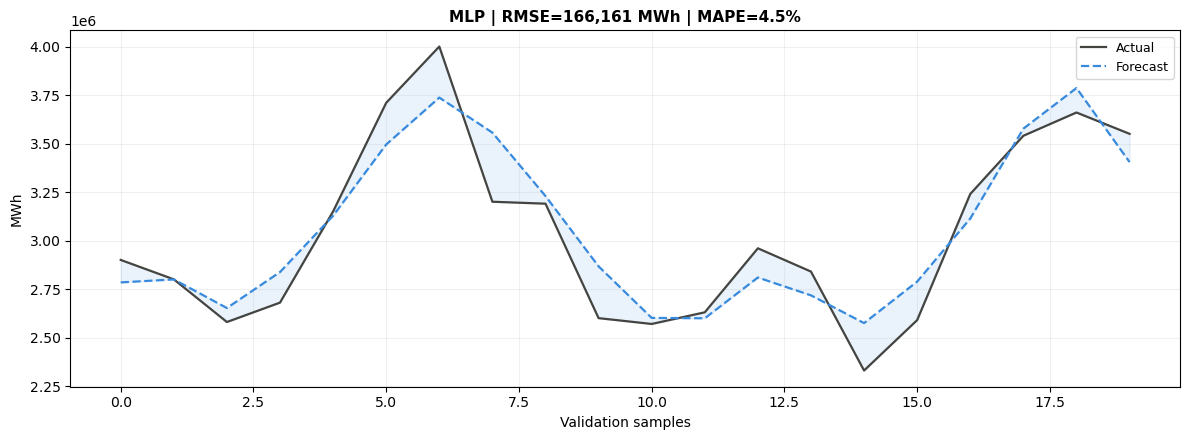

In [78]:
# ── MLP Forecast vs Actual ───────────────────────────────────────────────

rmse, mape, y_pred, y_real = results['MLP']

fig, ax = plt.subplots(figsize=(12, 4.5))

x = range(len(y_real))

ax.plot(
    x,
    y_real,
    color='#444441',
    lw=1.6,
    label='Actual',
    zorder=3
)

ax.plot(
    x,
    y_pred,
    color=palette['MLP'],
    lw=1.6,
    ls='--',
    label='Forecast',
    zorder=4
)

ax.fill_between(
    x,
    y_real,
    y_pred,
    alpha=0.1,
    color=palette['MLP']
)

ax.set_title(
    f'MLP | RMSE={rmse:,.0f} MWh | MAPE={mape:.1f}%',
    fontsize=11,
    fontweight='bold'
)

ax.set_xlabel('Validation samples')
ax.set_ylabel('MWh')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.18)

plt.tight_layout()
plt.show()

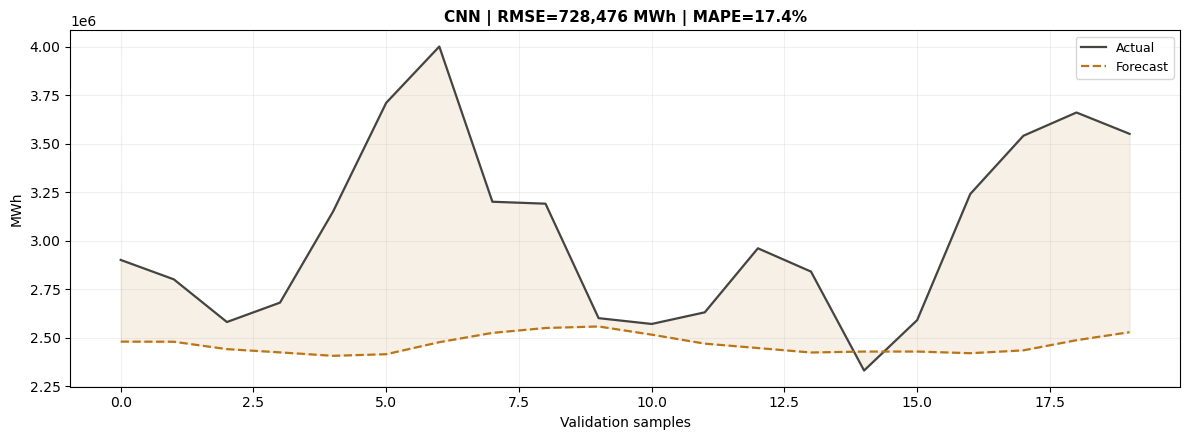

In [79]:
# ── CNN Forecast vs Actual ───────────────────────────────────────────────

rmse, mape, y_pred, y_real = results['CNN']

fig, ax = plt.subplots(figsize=(12, 4.5))

x = range(len(y_real))

ax.plot(
    x,
    y_real,
    color='#444441',
    lw=1.6,
    label='Actual',
    zorder=3
)

ax.plot(
    x,
    y_pred,
    color=palette['CNN'],
    lw=1.6,
    ls='--',
    label='Forecast',
    zorder=4
)

ax.fill_between(
    x,
    y_real,
    y_pred,
    alpha=0.1,
    color=palette['CNN']
)

ax.set_title(
    f'CNN | RMSE={rmse:,.0f} MWh | MAPE={mape:.1f}%',
    fontsize=11,
    fontweight='bold'
)

ax.set_xlabel('Validation samples')
ax.set_ylabel('MWh')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.18)

plt.tight_layout()
plt.show()

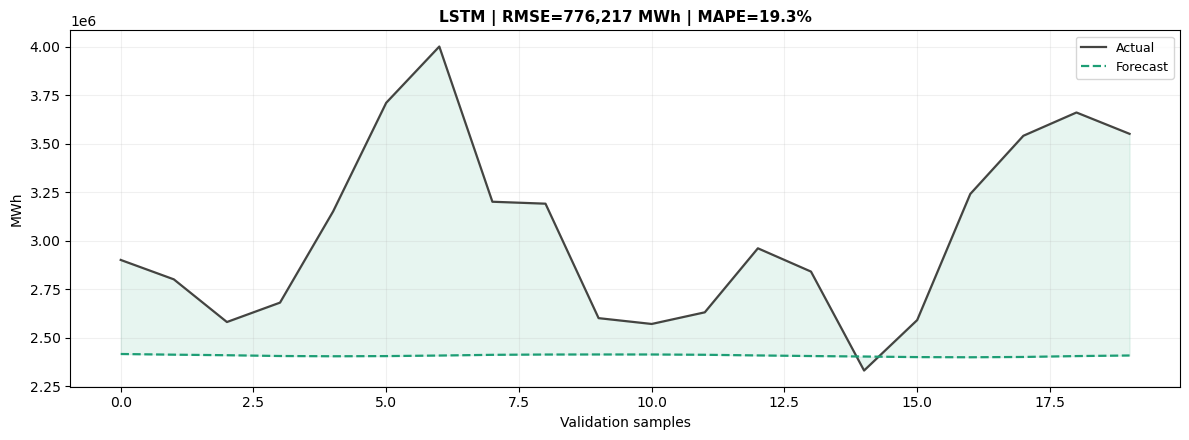

In [80]:
rmse, mape, y_pred, y_real = results['LSTM']

fig, ax = plt.subplots(figsize=(12, 4.5))

x = range(len(y_real))

ax.plot(
    x,
    y_real,
    color='#444441',
    lw=1.6,
    label='Actual',
    zorder=3
)

ax.plot(
    x,
    y_pred,
    color=palette['LSTM'],
    lw=1.6,
    ls='--',
    label='Forecast',
    zorder=4
)

ax.fill_between(
    x,
    y_real,
    y_pred,
    alpha=0.1,
    color=palette['LSTM']
)
ax.set_title(
    f'LSTM | RMSE={rmse:,.0f} MWh | MAPE={mape:.1f}%',
    fontsize=11,
    fontweight='bold'
)

ax.set_xlabel('Validation samples')
ax.set_ylabel('MWh')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.18)

plt.tight_layout()
plt.show()

In [81]:
# ── Create test sequences ────────────────────────────────────────────────


full_scaled = scaler.transform(df[['target']]).flatten()

X_all, y_all = create_sequences(full_scaled, WINDOW, LAG)

# Keep only sequences belonging to test period
X_test = X_all[-TEST_N:]
y_test = y_all[-TEST_N:]

# 3D reshape for CNN/LSTM
X_test_3d = X_test.reshape(*X_test.shape, 1)

print('X_test shape :', X_test.shape)
print('y_test shape :', y_test.shape)

X_test shape : (12, 12)
y_test shape : (12,)


In [82]:
# ── Final predictions on TEST period ────────────────────────────────────

test_predictions = {}

for name, model in models.items():

    if name == 'MLP':

        pred_scaled = model.predict(
            X_test,
            verbose=0
        )

    else:

        pred_scaled = model.predict(
            X_test_3d,
            verbose=0
        )

    # Back to original scale
    pred = scaler.inverse_transform(
        pred_scaled.reshape(-1,1)
    ).flatten()

    test_predictions[name] = pred

# Real test values
real_test = scaler.inverse_transform(
    y_test.reshape(-1,1)
).flatten()

print('Test predictions completed.')

Test predictions completed.


In [83]:
# ── Test metrics ─────────────────────────────────────────────────────────

def evaluate_test(name, y_pred, y_real):

    rmse = np.sqrt(
        mean_squared_error(y_real, y_pred)
    )

    mape = np.mean(
        np.abs((y_real - y_pred) / y_real)
    ) * 100

    return rmse, mape, y_pred, y_real



results_test = {
    name: evaluate_test(name, pred, real_test)
    for name, pred in test_predictions.items()
}




print('\nTest Results:')
print(f'{"Model":<12}  {"RMSE (MWh)":>12}  {"MAPE (%)":>10}  {"Params":>10}')
print('─' * 52)
for name, (rmse, mape, _, _) in results_test.items():

    n_params = models[name].count_params()

    print(
        f'{name:<12}  '
        f'{rmse:>12,.1f}  '
        f'{mape:>9.2f}%  '
        f'{n_params:>10,}'
    )


Test Results:
Model           RMSE (MWh)    MAPE (%)      Params
────────────────────────────────────────────────────
MLP              226,442.2       6.03%       6,401
CNN              682,355.1      14.63%      16,293
LSTM             727,894.5      16.06%      10,451


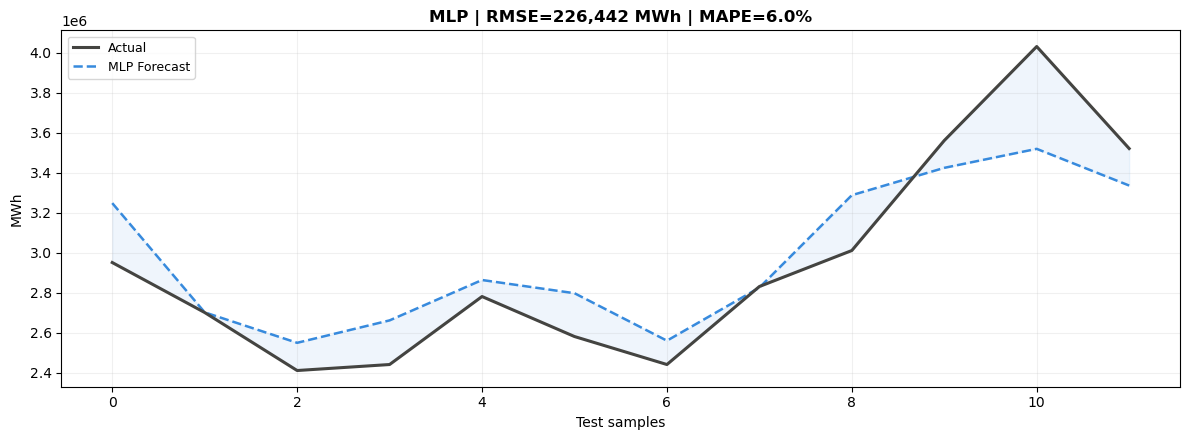

In [84]:
# ── MLP Final Forecast vs Actual ────────────────────────────────────────
rmse, mape, y_pred, y_real = results_test['MLP']
fig, ax = plt.subplots(figsize=(12, 4.5))

pred = test_predictions['MLP']

ax.plot(
    real_test,
    color='#444441',
    linewidth=2.2,
    label='Actual',
    zorder=5
)

ax.plot(
    pred,
    color=palette['MLP'],
    linewidth=1.8,
    linestyle='--',
    label='MLP Forecast',
    zorder=4
)

ax.fill_between(
    range(len(real_test)),
    real_test,
    pred,
    color=palette['MLP'],
    alpha=0.08
)

ax.set_title(
 
    f'MLP | RMSE={rmse:,.0f} MWh | MAPE={mape:.1f}%',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel('Test samples')
ax.set_ylabel('MWh')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.18)

plt.tight_layout()
plt.show()

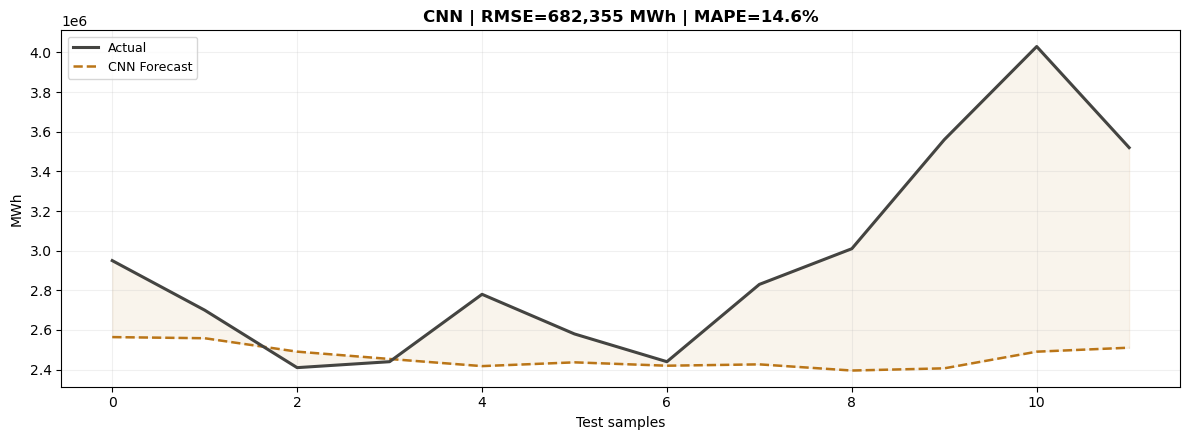

In [85]:
# ── CNN Final Forecast vs Actual ────────────────────────────────────────
rmse, mape, y_pred, y_real = results_test['CNN']
fig, ax = plt.subplots(figsize=(12, 4.5))

pred = test_predictions['CNN']

ax.plot(
    real_test,
    color='#444441',
    linewidth=2.2,
    label='Actual',
    zorder=5
)

ax.plot(
    pred,
    color=palette['CNN'],
    linewidth=1.8,
    linestyle='--',
    label='CNN Forecast',
    zorder=4
)

ax.fill_between(
    range(len(real_test)),
    real_test,
    pred,
    color=palette['CNN'],
    alpha=0.08
)

ax.set_title(
    
    f'CNN | RMSE={rmse:,.0f} MWh | MAPE={mape:.1f}%',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel('Test samples')
ax.set_ylabel('MWh')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.18)

plt.tight_layout()
plt.show()

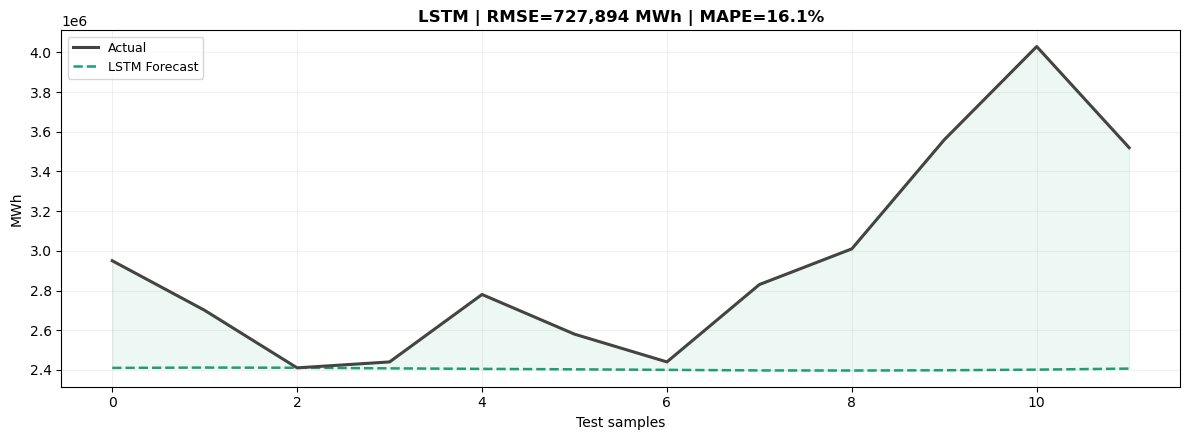

In [86]:
# ── LSTM Final Forecast vs Actual ───────────────────────────────────────
rmse, mape, y_pred, y_real = results_test['LSTM']
fig, ax = plt.subplots(figsize=(12, 4.5))

pred = test_predictions['LSTM']

ax.plot(
    real_test,
    color='#444441',
    linewidth=2.2,
    label='Actual',
    zorder=5
)

ax.plot(
    pred,
    color=palette['LSTM'],
    linewidth=1.8,
    linestyle='--',
    label='LSTM Forecast',
    zorder=4
)

ax.fill_between(
    range(len(real_test)),
    real_test,
    pred,
    color=palette['LSTM'],
    alpha=0.08
)

ax.set_title(
    
    f'LSTM | RMSE={rmse:,.0f} MWh | MAPE={mape:.1f}%',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel('Test samples')
ax.set_ylabel('MWh')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.18)

plt.tight_layout()
plt.show()